# Weather Classification Technical Report
CPSC-322 Data Science | Fall 2025 | Written by Aiden Tabrah & Valon Haslem

### Introduction


#### 1) Overview:
[Weather Category Dataset](https://www.kaggle.com/datasets/muthuj7/weather-dataset) is a .csv file with 96.5k instances and 12 attributes. The attribute being selected for classification is the "summary" attribute, which weather predictors use to classify weather conditions in short descriptions.

#### 2) Description:
We will be using 10 non-classification attributes for training our classifiers, out of the 12. The layoyut of the dataset is as follows:  
  
**Summary**                     - Various classification labels such as "Partly Cloudy" or "Mostly Cloudy"   
 ___
**Date**                 - Dates from 2005 to 2016  
**Precip-type**               - rain, snow, or other   
**Temperature (C)**                 - Temperature in celsius from -21.8 to 39.9  
**Apparent Temperature (C)**                   -  How it "feels" outside due to wind or other conditions. Ranges from -27.7 to 39.3  
**Humidity**                      - Percentage between 0.00 and 1.00  
**Wind Speed (km/h)**           - Wind speed in kilometers per hour, from 0 to 63.9  
**Wind Bearing (degrees)**              - Wind direction from 0 to 359  
**Visibility (km)**                 - How far one should be able to see, in kilometers.  
**Pressure (millibars)**               - Pressure from 0 to 1.05k  
**Loud Cover** - Potentially cloud cover? All data values are 0.0 though. (Will not be used)  
**Daily Summary** - A more descriptive classification of the data, that isn't standardized and varies more often. (Will not be used)


#### 3) Findings:
We tested the Random Forest, Decision Tree, and Naive Bayes after discretizing our continuous variables into 'high' or 'low' and restricting our classifer distribution to overcast, mostly cloudy, partly cloudy, foggy, and clear. The Random Forest (N = 20, M = 5, F = 4 was best) got 44% accuracy, Decision Tree got 46%, and Naive Bayes got 43%. By accuracy and precision, our best classifier is the Decision Tree at 39% precision, whereas Random Forest produced 32% precision and Naive Bayes 35% precision respectively. While the decision tree produced the best classifer, it was still not better than 50% accuracy. Future work should prune the tree to try to eliminate rules that don't add much information to the classifer and may be less accurate predictors.

#### Imports

In [2]:
from mysklearn.myclassifiers import MyDummyClassifier
from tabulate import tabulate
import importlib

import mysklearn.myutils
importlib.reload(mysklearn.myutils)
import mysklearn.myutils as myutils

import mysklearn.mypytable
importlib.reload(mysklearn.mypytable)
from mysklearn.mypytable import MyPyTable 

import mysklearn.myclassifiers
importlib.reload(mysklearn.myclassifiers)
from mysklearn.myclassifiers import MyDecisionTreeClassifier
from mysklearn.myclassifiers import MyNaiveBayesClassifier

import mysklearn.myevaluation
importlib.reload(mysklearn.myevaluation)
import mysklearn.myevaluation as myevaluation
from mysklearn.myclassifiers import MyRandomForestClassifier

# Constants:
k = 10
seed = 1

#### Data Cleaning / Setup

There were a couple attributes that needed cleaning, and we used these strategies for the following attribtues:
- Pressure - 0.0 pressure is not a legitimate value, and we replaced those invalid values with the mean pressure of the dataset.
- Missing values - any instance with a missing value is removed from the dataset.
- Date - needs to be dropped, not a useful thing.
- Precip-type - Since this has a ton of other values, it should be dropped.
- All attributes - all remaining attributes besides the classification are continuous. They should be normalized.

In [3]:

weather_data = MyPyTable().load_from_file("input-data/weatherHistory.csv")
weather_data.remove_rows_with_missing_values()
weather_data.save_to_file("output-data/weatherHistory_cleaned.csv")

weather_data.replace_column("Formatted Date", myutils.convert_date_to_numeric(weather_data.get_column("Formatted Date")))
# replace pressure zero values with mean

weather_data.replace_column('Pressure (millibars)', myutils.convert_zeros_to_mean(weather_data.get_column('Pressure (millibars)')))
weather_data.normalize_values(["Formatted Date", "Temperature (C)","Apparent Temperature (C)",
                               "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"])

weather_data.save_to_file("output-data/weatherHistory_normalized_and_cleaned.csv")

#### Loading data

In [4]:
weather_data = MyPyTable().load_from_file("output-data/weatherHistory_normalized_and_cleaned.csv")

ys = [val[0] for val in weather_data.select_columns(["Summary"]).data]
weather_x_data = weather_data.select_columns(["Temperature (C)", "Apparent Temperature (C)",
                                      "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"])
xs = weather_x_data.data


#### Drop to only 7148 instances per class
Classes restricted to Overcast, Mostly Cloudy, Partly Cloudy, Clear, and Foggy. The smallest is Foggy with 7148 instances, so only the first 7148 cases of each class value are taken. This makes the data even across possible classes, which will be helpful for classifer accuracy. It also removes all of super rare other classes that won't be picked up easily by the classifiers.

In [5]:
allowed = {'Overcast', 'Partly Cloudy', 'Mostly Cloudy', 'Clear', 'Foggy'}
limit = 7148

counts = {val: 0 for val in allowed}
all_xs = []
all_ys = []
for i, row  in enumerate(xs):
    y_val = ys[i]
    if y_val in allowed and counts[y_val] < limit:
        all_xs.append(row)
        all_ys.append(y_val)
        counts[y_val] += 1

We use boxplots analyze the data distribution of each continuous attribute. When we discretize the data, we want to figure out which attributes have outliers (and thus should be split on the median) versus attributes that don't, and therefore should be split on the mean. We determine all have outliers except for Wind Bearing and Visibility.

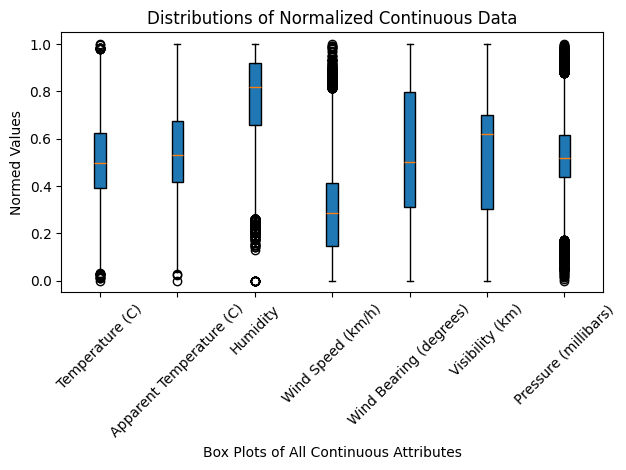

In [6]:
# box plots for continuous data
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

weather_cts_data_transposed = [list(row) for row in zip(*all_xs)]

for idx, data in enumerate(weather_cts_data_transposed):
    # first, normalize it
    new_data = myutils.norm_list(data)
    ax.boxplot(new_data, positions = [idx], patch_artist=True)


ax.set_xticks(range(len(weather_cts_data_transposed)))
ax.set_xticklabels(["Temperature (C)", 
                    "Apparent Temperature (C)",
                    "Humidity", 
                    "Wind Speed (km/h)", 
                    "Wind Bearing (degrees)", 
                    "Visibility (km)", 
                    "Pressure (millibars)"])
plt.xticks(rotation = 45)
ax.set_title("Distributions of Normalized Continuous Data")
ax.set_ylabel('Normed Values')
ax.set_xlabel('Box Plots of All Continuous Attributes')
plt.tight_layout()
plt.show()


#### Relationships

While Temperature and Apparent Temperature have a trivial positive relationship, temperature against humidity and pressure against humidity don't have an obvious correlation even when distinguishing by class. This indicates that no single classifer may be very good at identifying these groupings without additional steps being taken. We will discretize as "high" or "low", but we could take additional steps to determine clustering using a k-means algorithm or a similar approach. 

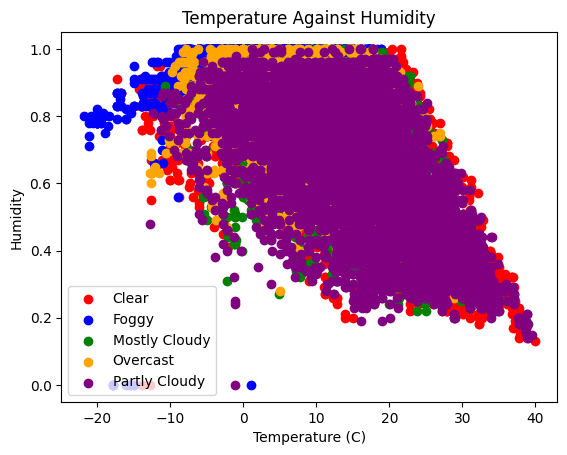

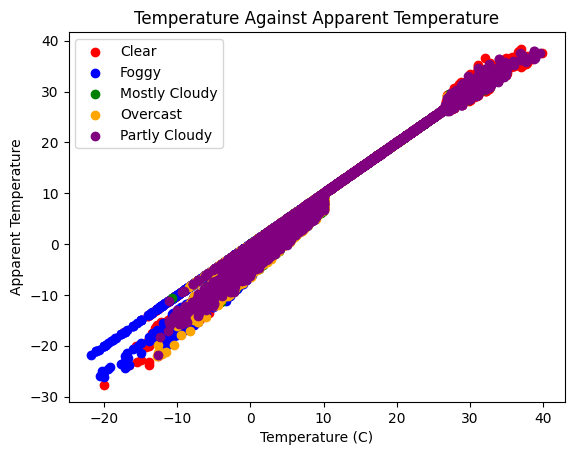

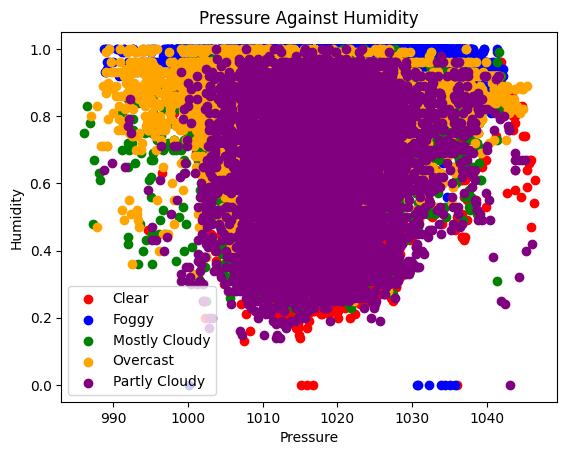

In [7]:
import numpy as np
transposed_xs = [list(row) for row in zip(*all_xs)]
humidity = np.array(transposed_xs[2])
temperature = np.array(transposed_xs[0])
pressure = np.array(transposed_xs[6]) # 6
app_temp = np.array( transposed_xs[1]) # 1

summary = np.array(all_ys) 
unique_vals = sorted(set(summary))

color_map = dict(zip(unique_vals, ['red', 'blue', 'green', 'orange', 'purple']))
plt.figure()
for val in unique_vals:
    mask = (summary == val)
    plt.scatter(temperature[mask], humidity[mask], color=color_map[val], label=val)

plt.legend()
plt.xlabel('Temperature (C)')
plt.ylabel('Humidity')
plt.title('Temperature Against Humidity')
plt.show()


plt.figure()
for val in unique_vals:
    mask = (summary == val)
    plt.scatter(temperature[mask], app_temp[mask], color=color_map[val], label=val)

plt.legend()
plt.xlabel('Temperature (C)')
plt.ylabel('Apparent Temperature')
plt.title('Temperature Against Apparent Temperature')
plt.show()

plt.figure()
for val in unique_vals:
    mask = (summary == val)
    plt.scatter(pressure[mask], humidity[mask], color=color_map[val], label=val)

plt.legend()
plt.xlabel('Pressure')
plt.ylabel('Humidity')
plt.title('Pressure Against Humidity')
plt.show()


# plt.scatter(x = temperature, y = app_temp, c = 'red')
# plt.title('Temperature Against Humidity')

# plt.show()

#### Discretize each continuous row.
Use mean or median based on whether outliers exist, since outliers have a pronounced effect on the mean and don't really affect the median.

Wind Bearing and Visibility is split on the mean, while all other attributes are split on the median.

In [8]:
num_features = 7
weather_disc_data = []  # holds only discretized X columns

for i in range(num_features):   # e.g. 7
    new_col = [float(x) for x in weather_cts_data_transposed[i]]
    crit_bool = (i == 4 or i == 5)
    discretized_col = myutils.high_low_discretizer(new_col, crit_bool)
    weather_disc_data.append(discretized_col)

# Add y separately
ys = all_ys

# Now transpose ONLY the X columns properly
disc_prepped_weather = list(zip(*weather_disc_data))

# X and y
discretized_xs = [list(disc_prepped_weather[i]) for i in range(len(disc_prepped_weather))]

#### Comparing Classifiers
Random Forest - We hypothesize this to be our best classifer because the hyperparameters should allow this to be tuned to produce a very accurate classifier. We concluded the best hyperparameters were N = 20, M = 5, F = 5.
Decision Tree - This should be useful because the decision rules could provide key insights on how certain weather patterns can be predicted.
Naive Bayes - This should account for certain levels of randomness that occur in weather patterns, and potentially swing into being a favorable predictor due to these probabilities being used.

Set of possible cols: {'Overcast', 'Partly Cloudy', 'Mostly Cloudy', 'Clear', 'Foggy'}

All classifiers use a stratified k-fold split. In addition, the subset of data taken will guarantee that every class has equal probability in the dataset.

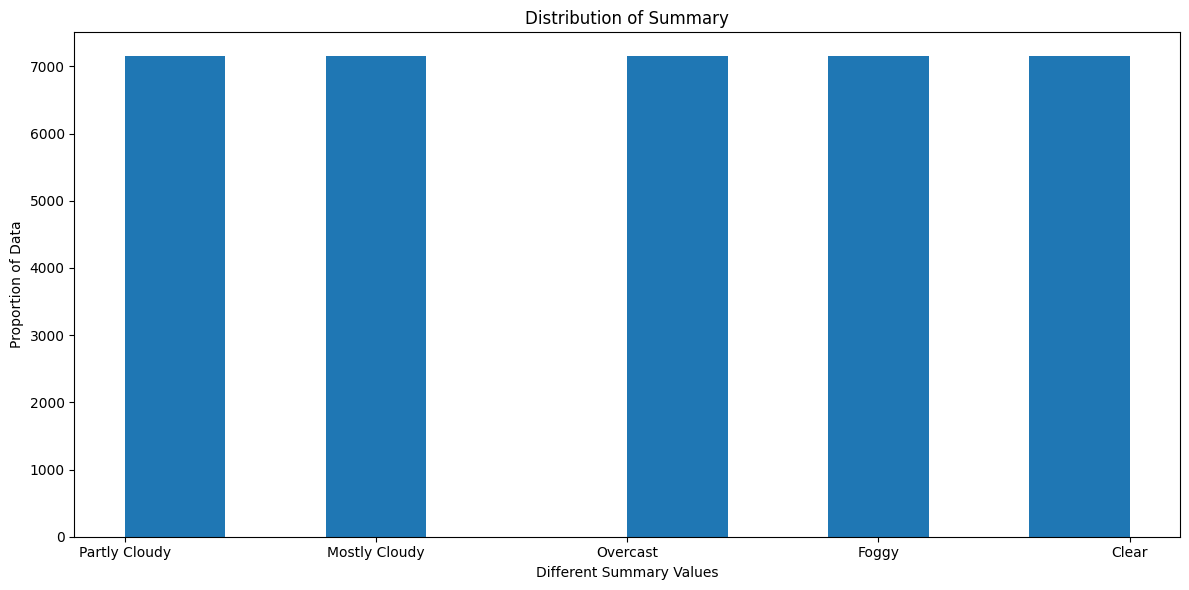

In [9]:

summary_col = all_ys
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.hist(x = summary_col)
plt.title('Distribution of Summary')
plt.xlabel('Different Summary Values')
plt.ylabel('Proportion of Data')
plt.tight_layout()
plt.show()


#### Random Forest

Accuracy and precision were lower than we initially predicted, but N = 20, M = 5, F = 5 seems to produce the most accurate results.

In [11]:
# hyperparameters N, M, F dont forget to tune
forest_classifier = MyRandomForestClassifier(20, 5, 5, seed)

y_possibilities = list(set(all_ys))

forest_classifier.fit(discretized_xs, all_ys)
accuracy, error, fold_predicted, fold_true = myutils.cross_val_predict(forest_classifier, discretized_xs, all_ys, num_splits=k, random_state=seed, stratified= True)

precision = myutils.myevaluation.binary_precision_score(fold_predicted, fold_true)
recall = myutils.myevaluation.binary_recall_score(fold_predicted, fold_true)
f1_score = myutils.myevaluation.binary_f1_score(fold_predicted, fold_true)

headers = ["Summary", *y_possibilities, "Total", "Recognition (%)"]
matrix = myevaluation.confusion_matrix(fold_true, fold_predicted, y_possibilities)

print("===========================================")
print("Weather Classification Results")
print("===========================================")
print(f"Stratified {k}-Fold Cross Validation")
print("-------------------------------------------")
print(f"Random Forest Classifier: accuracy = {accuracy:.2f}, error rate = {error:.2f}")
print(f"Random Forest Classifier: Precision = {precision:.2f}, Recall = {recall:.2f}, F1 Score = {f1_score:.2f}")
print("-------------------------------------------")

print(f"Random Forest Classifier Confusion Matrix")
print(tabulate(myutils.confusion_matrix_to_table(matrix, y_possibilities), headers=headers, tablefmt="github", numalign="right"))

Weather Classification Results
Stratified 10-Fold Cross Validation
-------------------------------------------
Random Forest Classifier: accuracy = 0.44, error rate = 0.56
Random Forest Classifier: Precision = 0.31, Recall = 0.41, F1 Score = 0.35
-------------------------------------------
Random Forest Classifier Confusion Matrix
| Summary       |   Partly Cloudy |   Clear |   Foggy |   Mostly Cloudy |   Overcast |   Total |   Recognition (%) |
|---------------|-----------------|---------|---------|-----------------|------------|---------|-------------------|
| Partly Cloudy |            3371 |    1522 |     550 |             863 |        842 |    7148 |                47 |
| Clear         |            2058 |    2330 |    1301 |             716 |        743 |    7148 |                33 |
| Foggy         |               2 |      73 |    6839 |               3 |        231 |    7148 |                96 |
| Mostly Cloudy |            2690 |    1287 |     771 |            1031 |       13

#### Decision Tree

Decision tree actually produced higher accuracy and higher precision than the random forest, so we should reject our hypothesis.

In [ ]:
tree_classifier = MyDecisionTreeClassifier()

y_possibilities = list(set(all_ys))

tree_classifier.fit(discretized_xs, all_ys)

accuracy, error, fold_predicted, fold_true = myutils.cross_val_predict(tree_classifier, discretized_xs, all_ys, num_splits=k, random_state=seed, stratified= True)

precision = myutils.myevaluation.binary_precision_score(fold_predicted, fold_true)
recall = myutils.myevaluation.binary_recall_score(fold_predicted, fold_true)
f1_score = myutils.myevaluation.binary_f1_score(fold_predicted, fold_true)

headers = ["Summary", *y_possibilities, "Total", "Recognition (%)"]
matrix = myevaluation.confusion_matrix(fold_true, fold_predicted, y_possibilities)

print("===========================================")
print("Weather Classification Results")
print("===========================================")
print(f"Stratified {k}-Fold Cross Validation")
print("-------------------------------------------")
print(f"Decision Tree Classifier: accuracy = {accuracy:.2f}, error rate = {error:.2f}")
print(f"Decision Tree Classifier: Precision = {precision:.2f}, Recall = {recall:.2f}, F1 Score = {f1_score:.2f}")
print("-------------------------------------------")

print(f"Decision Tree Classifier Confusion Matrix")
print(tabulate(myutils.confusion_matrix_to_table(matrix, y_possibilities), headers=headers, tablefmt="github", numalign="right"))


Weather Classification Results
Stratified 10-Fold Cross Validation
-------------------------------------------
Decision Tree Classifier: accuracy = 0.46, error rate = 0.54
Decision Tree Classifier: Precision = 0.39, Recall = 0.44, F1 Score = 0.41
-------------------------------------------
Decision Tree Classifier Confusion Matrix
| Summary       |   Partly Cloudy |   Overcast |   Clear |   Mostly Cloudy |   Foggy |   Total |   Recognition (%) |
|---------------|-----------------|------------|---------|-----------------|---------|---------|-------------------|
| Partly Cloudy |            3596 |        772 |    1426 |             989 |     365 |    7148 |                50 |
| Overcast      |             960 |       2774 |     656 |             731 |    2027 |    7148 |                39 |
| Clear         |            2189 |        757 |    2215 |             938 |    1049 |    7148 |                31 |
| Mostly Cloudy |            2887 |       1348 |    1181 |            1212 |     5

#### Naive Bayes

Naive Bayes produced lower accuracy but higher precision than Random Forest, which could be explained by the design of the decision tree tending towards finding decision rules instead of choosing "highest" probabilities. However, it still has worse metrics than the Decision Tree, so it is not our best classifier.

In [ ]:
naiveClassifier = MyNaiveBayesClassifier()

naiveClassifier.fit(discretized_xs, all_ys)

accuracy, error, fold_predicted, fold_true = myutils.cross_val_predict(
  naiveClassifier, discretized_xs, all_ys, num_splits=k, random_state=seed, stratified=True)

precision = myutils.myevaluation.binary_precision_score(fold_predicted, fold_true)
recall = myutils.myevaluation.binary_recall_score(fold_predicted, fold_true)
f1_score = myutils.myevaluation.binary_f1_score(fold_predicted, fold_true)

headers = ["Summary", *y_possibilities, "Total", "Recognition (%)"]
matrix = myutils.myevaluation.confusion_matrix(fold_true, fold_predicted, y_possibilities)

print("===========================================")
print("Weather Classification Results")
print("===========================================")
print(f"Stratified {k}-Fold Cross Validation")
print("-------------------------------------------")
print(f"Naive Bayes Classifier: accuracy = {accuracy:.2f}, error rate = {error:.2f}")
print(f"Naive Bayes Classifier: Precision = {precision:.2f}, Recall = {recall:.2f}, F1 Score = {f1_score:.2f}")
print("-------------------------------------------")

print(f"Naive Bayes Classifier Confusion Matrix")
print(tabulate(myutils.confusion_matrix_to_table(matrix, y_possibilities), headers=headers, tablefmt="github", numalign="right"))

Weather Classification Results
Stratified 10-Fold Cross Validation
-------------------------------------------
Naive Bayes Classifier: accuracy = 0.43, error rate = 0.57
Naive Bayes Classifier: Precision = 0.35, Recall = 0.34, F1 Score = 0.35
-------------------------------------------
Naive Bayes Classifier Confusion Matrix
| Summary       |   Partly Cloudy |   Overcast |   Clear |   Mostly Cloudy |   Foggy |   Total |   Recognition (%) |
|---------------|-----------------|------------|---------|-----------------|---------|---------|-------------------|
| Partly Cloudy |            4271 |       1341 |    1029 |             200 |     307 |    7148 |                60 |
| Overcast      |            1146 |       2510 |     757 |             501 |    2234 |    7148 |                35 |
| Clear         |            3020 |       1399 |    1708 |             151 |     870 |    7148 |                24 |
| Mostly Cloudy |            3520 |       1766 |     986 |             441 |     435 |  

### Dummy Classifier
We used a dummy classifier that guesses the most frequent class. This produced an accuracy of 20%, which is expected since there are 5 classes with equal representation in the dataset. This serves as a baseline to compare our other classifiers against.

In [ ]:
dummyClassifier = MyDummyClassifier()

dummyClassifier.fit(discretized_xs, all_ys)

accuracy, error, fold_predicted, fold_true = myutils.cross_val_predict(
  dummyClassifier, discretized_xs, all_ys, num_splits=k, random_state=seed, stratified=True)

precision = myutils.myevaluation.binary_precision_score(fold_predicted, fold_true)
recall = myutils.myevaluation.binary_recall_score(fold_predicted, fold_true)
f1_score = myutils.myevaluation.binary_f1_score(fold_predicted, fold_true)

headers = ["Summary", *y_possibilities, "Total", "Recognition (%)"]
matrix = myutils.myevaluation.confusion_matrix(fold_true, fold_predicted, y_possibilities)

print("===========================================")
print("Weather Classification Results")
print("===========================================")
print(f"Stratified {k}-Fold Cross Validation")
print("-------------------------------------------")
print(f"Dummy Classifier: accuracy = {accuracy:.2f}, error rate = {error:.2f}")
print(f"Dummy Classifier: Precision = {precision:.2f}, Recall = {recall:.2f}, F1 Score = {f1_score:.2f}")
print("-------------------------------------------")

print(f"Naive Bayes Classifier Confusion Matrix")
print(tabulate(myutils.confusion_matrix_to_table(matrix, y_possibilities), headers=headers, tablefmt="github", numalign="right"))

Weather Classification Results
Stratified 10-Fold Cross Validation
-------------------------------------------
Dummy Classifier: accuracy = 0.20, error rate = 0.80
Dummy Classifier: Precision = 1.00, Recall = 0.20, F1 Score = 0.33
-------------------------------------------
Naive Bayes Classifier Confusion Matrix
| Summary       |   Partly Cloudy |   Overcast |   Clear |   Mostly Cloudy |   Foggy |   Total |   Recognition (%) |
|---------------|-----------------|------------|---------|-----------------|---------|---------|-------------------|
| Partly Cloudy |            7148 |          0 |       0 |               0 |       0 |    7148 |               100 |
| Overcast      |            7148 |          0 |       0 |               0 |       0 |    7148 |                 0 |
| Clear         |            7148 |          0 |       0 |               0 |       0 |    7148 |                 0 |
| Mostly Cloudy |            7148 |          0 |       0 |               0 |       0 |    7148 |    

#### Conclusion

Across accuracy and precision, the decision tree is the best classifier, causing us to reject our initial beliefs that the random forest would be our best predictor. While we were able to take a carefully chosen subset of the data so that it would behave better for classification, but we still struggled to produce a classifier with higher than 50% accuracy. This is because weather is something that cannot easily be predicted. Multiple other variables could be accounted for that simple classifers aren't equipped to deal with. This includes time dependent factors like prior weather, geographic location, and geospatial factors that can't easily be described in a single instance of data. To improve performance, we could determine the most frequently used decision rules and assign them additional weight and penalize the lesser used decision rules or look at pruning them entirely. While this removes some of our information, it could aid us in building a more accurate tree.  

#### Results:
Decision tree classifier had the best accuracy of 46%. Compared to the baseline which predicts the most frequent that got 20% accuracy, this is a major improvement to predicting the weather. In total, we had a difference of a 26% improvement in accuracy.

In [ ]:
print('================================================')
print('\nDecision Tree Rules\n')
print('================================================')
tree_classifier.print_decision_rules()



Decision Tree Rules

IF att5 == high AND att3 == high AND att2 == high AND att6 == high AND att4 == high AND att0 == high AND att1 == high THEN class = Overcast
IF att5 == high AND att3 == high AND att2 == high AND att6 == high AND att4 == high AND att0 == high AND att1 == low THEN class = Mostly Cloudy
IF att5 == high AND att3 == high AND att2 == high AND att6 == high AND att4 == high AND att0 == low AND att1 == low THEN class = Mostly Cloudy
IF att5 == high AND att3 == high AND att2 == high AND att6 == high AND att4 == low AND att0 == high AND att1 == high THEN class = Mostly Cloudy
IF att5 == high AND att3 == high AND att2 == high AND att6 == high AND att4 == low AND att0 == high AND att1 == low THEN class = Partly Cloudy
IF att5 == high AND att3 == high AND att2 == high AND att6 == high AND att4 == low AND att0 == low AND att1 == low THEN class = Overcast
IF att5 == high AND att3 == high AND att2 == high AND att6 == low AND att1 == high AND att4 == high AND att0 == high THEN class

#### Sources
-[Weather Category Dataset](https://www.kaggle.com/datasets/muthuj7/weather-dataset)

-Code used from prior PAs.

-Both authors contributed equally to this project.